## Testing NeuralGCM - St John's

NOTE TO SELF: Do not run this on your local machine. Will take a lot of storage and run slow.

Run this on a cluster, Google colab or $\text{PC}^*$ with a GPU/TPU.

In [2]:
! pip install -q -U neuralgcm dinosaur gcsfs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.0/175.0 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.7/77.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 94.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.3.0 which is incompatible.

In [ ]:
import jax
import numpy as np

import gcsfs  # Google Cloud Storage filesystem - reading directly from GCS storage buckets
# Python's serialization module - NeuralGCM model checkpoints (weights + configs) are stored as pickle files
import pickle
# N-dimensional labeled arrary library - ERA5 data comes in this format (dimensions: time, level, latitude, longitude)
import xarray

# dinosaur is neuralgcm's dynamics package
from dinosaur import horizontal_interpolation
from dinosaur import spherical_harmonic
from dinosaur import xarray_utils

import neuralgcm

### Load a pre-trained NeuralGCM model


In [ ]:
# @param ['v1/deterministic_0_7_deg.pkl', 'v1/deterministic_1_4_deg.pkl', 'v1/deterministic_2_8_deg.pkl', 'v1/stochastic_1_4_deg.pkl', 'v1_precip/stochastic_precip_2_8_deg.pkl', 'v1_precip/stochastic_evap_2_8_deg.pkl'] {type: "string"}
model_name = 'v1/deterministic_2_8_deg.pkl'

gcs = gcsfs.GCSFileSystem(token='anon')
with gcs.open(f'gs://neuralgcm/models/{model_name}', 'rb') as f:
    ckpt = pickle.load(f)

model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)

### Load ERA5 data from GCP/Zarr

Because we are loading the data from Zarr / GCP (Google Cloud Platform), we don't need to download the full 30 years dataset.

In [6]:
era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
full_era5 = xarray.open_zarr(
    era5_path, chunks=None, storage_options=dict(token='anon')
)

demo_start_time = '2020-02-14'
demo_end_time = '2020-02-18'
data_inner_steps = 24  # process every 24th hour

sliced_era5 = (
    full_era5
    [model.input_variables + model.forcing_variables]
    .pipe(
        xarray_utils.selective_temporal_shift,
        variables=model.forcing_variables,
        time_shift='24 hours',
    )
    .sel(time=slice(demo_start_time, demo_end_time, data_inner_steps))
    .compute()
)

Regrid to NeuralGCM’s native resolution:

In [7]:
era5_grid = spherical_harmonic.Grid(
    latitude_nodes=full_era5.sizes['latitude'],
    longitude_nodes=full_era5.sizes['longitude'],
    latitude_spacing=xarray_utils.infer_latitude_spacing(full_era5.latitude),
    longitude_offset=xarray_utils.infer_longitude_offset(full_era5.longitude),
)
regridder = horizontal_interpolation.ConservativeRegridder(
    era5_grid, model.data_coords.horizontal, skipna=True
)
eval_era5 = xarray_utils.regrid(sliced_era5, regridder)
eval_era5 = xarray_utils.fill_nan_with_nearest(eval_era5)

## Make a forecast

In [8]:
inner_steps = 24  # save model outputs once every 24 hours
outer_steps = 4 * 24 // inner_steps  # total of 4 days
timedelta = np.timedelta64(1, 'h') * inner_steps
times = (np.arange(outer_steps) * inner_steps)  # time axis in hours

# initialize model state
inputs = model.inputs_from_xarray(eval_era5.isel(time=0))
input_forcings = model.forcings_from_xarray(eval_era5.isel(time=0))
rng_key = jax.random.key(42)  # optional for deterministic models
initial_state = model.encode(inputs, input_forcings, rng_key)

# use persistence for forcing variables (SST and sea ice cover)
all_forcings = model.forcings_from_xarray(eval_era5.head(time=1))

# make forecast
final_state, predictions = model.unroll(
    initial_state,
    all_forcings,
    steps=outer_steps,
    timedelta=timedelta,
    start_with_input=True,
)
predictions_ds = model.data_to_xarray(predictions, times=times)

In [9]:
predictions_ds

<xarray.Dataset> Size: 34MB
Dimensions:                              (time: 4, level: 37, longitude: 128,
                                          latitude: 64)
Coordinates:
  * time                                 (time) int64 32B 0 24 48 72
  * level                                (level) int64 296B 1 2 3 ... 975 1000
  * longitude                            (longitude) float64 1kB 0.0 ... 357.2
  * latitude                             (latitude) float64 512B -87.86 ... 8...
Data variables:
    specific_cloud_ice_water_content     (time, level, longitude, latitude) float32 5MB ...
    specific_humidity                    (time, level, longitude, latitude) float32 5MB ...
    geopotential                         (time, level, longitude, latitude) float32 5MB ...
    v_component_of_wind                  (time, level, longitude, latitude) float32 5MB ...
    specific_cloud_liquid_water_content  (time, level, longitude, latitude) float32 5MB ...
    temperature                          (time, level, longitude, latitude) float32 5MB ...
    u_component_of_wind                  (time, level, longitude, latitude) float32 5MB ...
    sim_time                             (time) float32 16B ...
Attributes:
    longitude_wavenumbers:     64
    total_wavenumbers:         65
    longitude_nodes:           128
    latitude_nodes:            64
    latitude_spacing:          gauss
    longitude_offset:          0.0
    radius:                    1.0
    spherical_harmonics_impl:  RealSphericalHarmonics
    spmd_mesh:                 
    centers:                   [1, 2, 3, 5, 7, 10, 20, 30, 50, 70, 100, 125, ...
    horizontal_grid_type:      Grid
    vertical_grid_type:        PressureCoordinates

## Compare Predictions to ERA5

In [11]:
# Selecting ERA5 targets from exactly the same time slice
target_trajectory = model.inputs_from_xarray(
    eval_era5
    .thin(time=(inner_steps // data_inner_steps))
    .isel(time=slice(outer_steps))
)
target_data_ds = model.data_to_xarray(target_trajectory, times=times)

combined_ds = xarray.concat([target_data_ds, predictions_ds], 'model')
combined_ds.coords['model'] = ['ERA5', 'NeuralGCM']

Let's check the resolution of the `full_era5` dataset.

In [13]:
print(f"ERA5 Latitude: {full_era5.latitude.min().item()} to {full_era5.latitude.max().item()} with {len(full_era5.latitude)} points.")
print(f"ERA5 Longitude: {full_era5.longitude.min().item()} to {full_era5.longitude.max().item()} with {len(full_era5.longitude)} points.")

# Calculate approximate resolution
lat_diff = np.abs(full_era5.latitude.diff('latitude').item(0))
lon_diff = np.abs(full_era5.longitude.diff('longitude').item(0))
print(f"Approximate Latitude Resolution: {lat_diff:.2f} degrees")
print(f"Approximate Longitude Resolution: {lon_diff:.2f} degrees")

ERA5 Latitude: -90.0 to 90.0 with 721 points.
ERA5 Longitude: 0.0 to 359.75 with 1440 points.
Approximate Latitude Resolution: 0.25 degrees
Approximate Longitude Resolution: 0.25 degrees


The above results show that, ERA5 has an approximate resolution of about 0.25degs

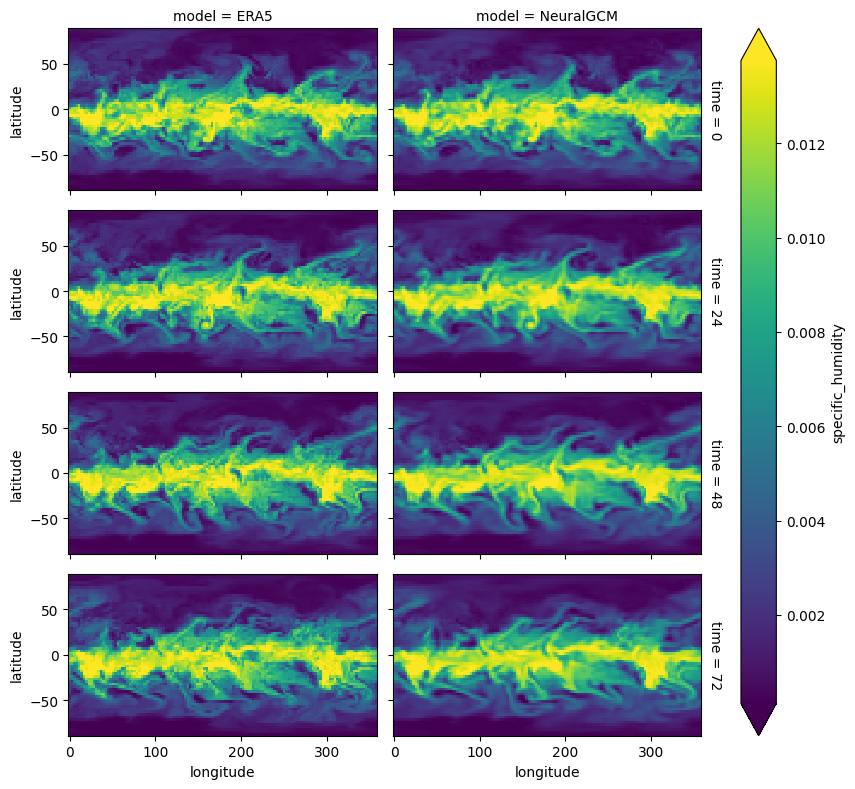

In [ ]:
# Visualize ERA5 vs NeuralGCM trajectories
combined_ds.specific_humidity.sel(level=850).plot(
    x='longitude', y='latitude', row='time', col='model', robust=True, aspect=2, size=2
)

## Results at St. John's, NL

St. John's is at approximately **47.56°N, 52.71°W** (≈ 307.29°E in 0–360 convention).

Note: this model is the 2.8° deterministic checkpoint, so the nearest grid point will be offset from the true city location by up to ~1.4° in each direction. For finer analysis, switch `model_name` to `v1/deterministic_0_7_deg.pkl`.

In [ ]:
# St. John's, NL coordinates (0-360 longitude convention)
stjohns_lat = 47.5615
stjohns_lon = 360.0 - 52.7126  # ≈ 307.29

stjohns_ds = combined_ds.sel(
    latitude=stjohns_lat, longitude=stjohns_lon, method='nearest'
)
print(
    f"Requested:    lat={stjohns_lat:.2f}, lon={stjohns_lon:.2f}\n"
    f"Nearest grid: lat={float(stjohns_ds.latitude):.2f}, "
    f"lon={float(stjohns_ds.longitude):.2f}"
)
stjohns_ds

### Visualize the grid that gets sampled

The model uses a Gaussian latitude grid (64 × 128 points at 2.8°), so the nearest grid point can be ~150 km off. Plot all grid points in the region, mark St. John's, and outline the cell we actually sample from.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model_lats = combined_ds.latitude.values
model_lons = combined_ds.longitude.values
nearest_lat = float(stjohns_ds.latitude)
nearest_lon = float(stjohns_ds.longitude)

fig, (ax_g, ax_r) = plt.subplots(1, 2, figsize=(14, 5))

# --- Global grid view ---
LO, LA = np.meshgrid(model_lons, model_lats)
ax_g.scatter(LO, LA, s=1, color='steelblue', alpha=0.4)
ax_g.scatter([stjohns_lon], [stjohns_lat], marker='*', s=200,
             color='red', edgecolor='black', zorder=5, label="St. John's")
ax_g.scatter([nearest_lon], [nearest_lat], marker='o', s=80,
             facecolor='yellow', edgecolor='black', zorder=4,
             label='nearest grid pt')
ax_g.set(xlabel='Longitude (°E)', ylabel='Latitude (°N)',
         title=f'Global NeuralGCM grid ({len(model_lats)} × {len(model_lons)})')
ax_g.set_xlim(0, 360); ax_g.set_ylim(-90, 90)
ax_g.legend(loc='lower left'); ax_g.grid(alpha=0.2)

# --- Regional zoom with cell boundary for the nearest point ---
lat_mask = (model_lats >= 35) & (model_lats <= 60)
lon_mask = (model_lons >= 280) & (model_lons <= 330)
LOr, LAr = np.meshgrid(model_lons[lon_mask], model_lats[lat_mask])
ax_r.scatter(LOr, LAr, s=25, color='steelblue', alpha=0.6, label='grid points')

# Approximate cell boundary (midpoints to neighbouring grid lines)
def _bounds(arr, val):
    i = int(np.argmin(np.abs(arr - val)))
    lo = (arr[i - 1] + arr[i]) / 2 if i > 0 else arr[i] - (arr[i + 1] - arr[i]) / 2
    hi = (arr[i] + arr[i + 1]) / 2 if i < len(arr) - 1 else arr[i] + (arr[i] - arr[i - 1]) / 2
    return lo, hi

lat_lo, lat_hi = _bounds(model_lats, nearest_lat)
lon_lo, lon_hi = _bounds(model_lons, nearest_lon)
ax_r.add_patch(plt.Rectangle((lon_lo, lat_lo), lon_hi - lon_lo, lat_hi - lat_lo,
                             fill=False, edgecolor='orange', linewidth=2,
                             label='sampled cell'))

ax_r.scatter([stjohns_lon], [stjohns_lat], marker='*', s=300,
             color='red', edgecolor='black', zorder=5, label="St. John's")
ax_r.scatter([nearest_lon], [nearest_lat], marker='o', s=120,
             facecolor='yellow', edgecolor='black', zorder=4,
             label='nearest grid pt')
ax_r.set(xlabel='Longitude (°E)', ylabel='Latitude (°N)',
         title='Atlantic Canada zoom')
ax_r.set_xlim(280, 330); ax_r.set_ylim(35, 60)
ax_r.legend(loc='lower left'); ax_r.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Distance from St. John's to the snapped grid point
dlat = (nearest_lat - stjohns_lat) * 111.0
dlon = (nearest_lon - stjohns_lon) * 111.0 * np.cos(np.deg2rad(stjohns_lat))
print(f"Offset from St. John's: Δlat={dlat:+.0f} km, Δlon={dlon:+.0f} km, "
      f"total ≈ {np.hypot(dlat, dlon):.0f} km")

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Near-surface temperature (1000 hPa)
for m in combined_ds.model.values:
    t_c = stjohns_ds.temperature.sel(level=1000, model=m).values - 273.15
    axes[0].plot(stjohns_ds.time, t_c, marker='o', label=m)
axes[0].set(
    xlabel='Forecast hour', ylabel='T at 1000 hPa (°C)',
    title="St. John's — near-surface T",
)
axes[0].legend()
axes[0].grid(alpha=0.3)

# 850 hPa specific humidity
for m in combined_ds.model.values:
    q = stjohns_ds.specific_humidity.sel(level=850, model=m).values * 1000
    axes[1].plot(stjohns_ds.time, q, marker='o', label=m)
axes[1].set(
    xlabel='Forecast hour', ylabel='q at 850 hPa (g/kg)',
    title="St. John's — 850 hPa moisture",
)
axes[1].legend()
axes[1].grid(alpha=0.3)

# 500 hPa geopotential height
g = 9.80665
for m in combined_ds.model.values:
    z = stjohns_ds.geopotential.sel(level=500, model=m).values / g
    axes[2].plot(stjohns_ds.time, z, marker='o', label=m)
axes[2].set(
    xlabel='Forecast hour', ylabel='Z500 (m)',
    title="St. John's — 500 hPa height",
)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Regional map around Newfoundland

Zoom in on the Atlantic Canada / Newfoundland region so we can see St. John's in context. The red marker is the requested city location; the actual sampled grid point is whichever cell it falls inside.

In [1]:
# Region: roughly Atlantic Canada and surrounding ocean
lat_min, lat_max = 35, 60
lon_min, lon_max = 280, 330

ds_region = combined_ds.sel(
    latitude=slice(lat_min, lat_max),
    longitude=slice(lon_min, lon_max),
)

fg = ds_region.temperature.sel(level=1000).plot(
    x='longitude', y='latitude', row='time', col='model',
    robust=True, aspect=1.2, size=2.8, cmap='RdBu_r',
    cbar_kwargs={'label': 'T at 1000 hPa (K)'},
)

# Mark St. John's on every subplot
for ax in fg.axs.flat:
    ax.plot(stjohns_lon, stjohns_lat, marker='*', markersize=12,
            color='black', markerfacecolor='yellow', markeredgewidth=1)

NameError: name 'combined_ds' is not defined